# Task 1 — GPT-Style LLM From Scratch (TinyStories)

**Author:** Khushi Donda · **Run ID:** `task1_full_20260925_204011` (full 10-epoch GPU run)

This notebook presents the completed Task 1 experiment using only already-committed evidence from
this repository: the tracked config/tokenizer/split metadata, the model source code, the committed
final checkpoint (`epoch_9.pt`), and the committed evaluation outputs (metrics, generations, loss
curves, failure candidates).

**This notebook does not retrain the model.** It does not require the gitignored `.npy` sequence
arrays, epochs 0-8 (not committed), the raw TinyStories dataset, or any local backup zip. All paths
below are relative to this notebook's own location (`task1_llm/khushi/`).


In [1]:
import json
import sys
from pathlib import Path

import torch

REPO_ROOT = Path.cwd().resolve().parents[1]  # task1_llm/khushi/ -> task1_llm -> repo root
TASK1_DIR = Path.cwd().resolve()             # task1_llm/khushi/
SRC_DIR = TASK1_DIR / "src"
sys.path.insert(0, str(SRC_DIR))

RUN_ID = "task1_full_20260925_204011"
EPOCH = 9

print("Repo root:      ", REPO_ROOT.name, "(repo-relative paths below are relative to this)")
print("Task 1 dir:     ", TASK1_DIR.relative_to(REPO_ROOT))
print("Run ID:         ", RUN_ID)
print("torch version:  ", torch.__version__)
print("CUDA available: ", torch.cuda.is_available())


Repo root:       DATA266-Lab1-Khushi-Dipin (repo-relative paths below are relative to this)
Task 1 dir:      task1_llm/khushi
Run ID:          task1_full_20260925_204011
torch version:   2.14.0
CUDA available:  False


## 1. Dataset and deterministic split

Source: `roneneldan/TinyStories` (Hugging Face), train split only, used as the sole source pool.
Khushi's subset is a seeded, non-overlapping split: 100,000 training stories and 10,000 validation
stories, verified below directly from the committed split indices (no need to re-download the raw
dataset to check this).

In [2]:
with open(TASK1_DIR / "data_processed" / "split_indices.json") as f:
    split_indices = json.load(f)

train_idx = split_indices["train_indices"]
val_idx = split_indices["validation_indices"]
overlap = set(train_idx) & set(val_idx)

print("Seed:                 ", split_indices["seed"])
print("Train stories:        ", len(train_idx))
print("Validation stories:   ", len(val_idx))
print("Train/validation overlap:", len(overlap))
assert len(train_idx) == 100_000
assert len(val_idx) == 10_000
assert len(overlap) == 0
print("\nVerified: 100,000 / 10,000 split, seed recorded, zero overlap.")


Seed:                  42
Train stories:         100000
Validation stories:    10000
Train/validation overlap: 0

Verified: 100,000 / 10,000 split, seed recorded, zero overlap.


## 2. Character-level tokenizer

Vocabulary built only from the training split's characters (sorted, deterministic). No pretrained
tokenizer is used.

In [3]:
with open(TASK1_DIR / "data_processed" / "tokenizer.json") as f:
    tokenizer = json.load(f)

vocab = tokenizer["vocab"]
char_to_idx = tokenizer["char_to_idx"]
idx_to_char = {i: ch for i, ch in enumerate(vocab)}

print("vocab_size:", tokenizer["vocab_size"])
print("First 20 vocab entries:", vocab[:20])

sample_text = "Once upon a time"
encoded = [char_to_idx[c] for c in sample_text]
decoded = "".join(idx_to_char[i] for i in encoded)
print("\nEncode/decode round-trip check:")
print(" text   :", repr(sample_text))
print(" encoded:", encoded)
print(" decoded:", repr(decoded))
assert decoded == sample_text


vocab_size: 110
First 20 vocab entries: ['\n', ' ', '!', '"', '$', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4']

Encode/decode round-trip check:
 text   : 'Once upon a time'
 encoded: [43, 73, 62, 64, 1, 80, 75, 74, 73, 1, 60, 1, 79, 68, 72, 64]
 decoded: 'Once upon a time'


## 3. Fixed-length sequence construction

Each story is split into non-overlapping 129-character windows (128 input characters + 1 shifted
target character); stories too short for one full window are skipped, no padding or cross-story
concatenation. Counts below are read from the committed `sequences_metadata.json` (produced when the
sequences were built) rather than regenerated here, since that would require the gitignored `.npy`
arrays and the raw dataset.

In [4]:
with open(TASK1_DIR / "data_processed" / "sequences_metadata.json") as f:
    seq_meta = json.load(f)

print(json.dumps(seq_meta, indent=2))


{
  "sequence_length": 128,
  "window_size": 129,
  "windowing_strategy": "non_overlapping_chunks_per_story",
  "train": {
    "num_stories_used": 99991,
    "num_stories_skipped_too_short": 9,
    "num_sequences": 644854
  },
  "validation": {
    "num_stories_used": 9999,
    "num_stories_skipped_too_short": 1,
    "num_sequences": 64576
  }
}


## 4. Model architecture

Decoder-only, GPT-style character-level language model:

```
token ids (B, T)
  --token_embedding-->      (B, T, C)
  --+ position_embedding--> (B, T, C)
  --N x TransformerBlock-->  (B, T, C)
  --final LayerNorm-->       (B, T, C)
  --lm_head (linear)-->      (B, T, vocab_size)   logits
```

Each `TransformerBlock` is pre-LayerNorm: `x = x + SelfAttention(LayerNorm(x))`, then
`x = x + FeedForward(LayerNorm(x))`. The model is built directly from the committed
`configs/task1_config.json` and `data_processed/tokenizer.json` -- the same function used for the
real training run (`model.build_model_from_config`).

In [5]:
from model import build_model_from_config

model, model_cfg = build_model_from_config()
print("Model config used:")
print(json.dumps(model_cfg, indent=2))
print("\n", model)


Model config used:
{
  "vocab_size": 110,
  "sequence_length": 128,
  "embedding_dim": 128,
  "num_heads": 4,
  "num_transformer_blocks": 4,
  "feed_forward_dim": 256,
  "dropout": 0.1
}

 GPT(
  (token_embedding): Embedding(110, 128)
  (position_embedding): Embedding(128, 128)
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): CausalSelfAttention(
        (query_proj): Linear(in_features=128, out_features=128, bias=True)
        (key_proj): Linear(in_features=128, out_features=128, bias=True)
        (value_proj): Linear(in_features=128, out_features=128, bias=True)
        (output_proj): Linear(in_features=128, out_features=128, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    

## 5. Manual causal multi-head self-attention

No prebuilt attention/Transformer module is used anywhere in this model -- no `nn.MultiheadAttention`,
`nn.Transformer`, or `nn.TransformerEncoder`. `CausalSelfAttention` implements scaled dot-product
attention by hand: explicit Q/K/V linear projections, a registered lower-triangular boolean mask
applied via `masked_fill(..., -inf)` before softmax, and manual multi-head split/merge. Source code
(from `src/model.py`, the exact code used for the committed run):

In [6]:
import inspect
from model import CausalSelfAttention

print(inspect.getsource(CausalSelfAttention))


class CausalSelfAttention(nn.Module):
    """Manual multi-head causal self-attention (no nn.MultiheadAttention).

    Input and output shape: (batch, seq_len, embedding_dim), written as
    (B, T, C) in the comments below.
    """

    def __init__(self, embedding_dim, num_heads, sequence_length, dropout):
        super().__init__()
        assert embedding_dim % num_heads == 0, "embedding_dim must be divisible by num_heads"

        self.num_heads = num_heads
        self.head_dim = embedding_dim // num_heads  # size of each head's Q/K/V vectors

        # One combined projection per Q/K/V that covers all heads at once:
        # (B, T, C) -> (B, T, C), later reshaped into per-head chunks.
        self.query_proj = nn.Linear(embedding_dim, embedding_dim)
        self.key_proj = nn.Linear(embedding_dim, embedding_dim)
        self.value_proj = nn.Linear(embedding_dim, embedding_dim)
        self.output_proj = nn.Linear(embedding_dim, embedding_dim)

        self.attn_dropout = nn.Dropo

## 6. Hyperparameters

Full config used by the committed run (`configs/task1_config.json`):

In [7]:
with open(TASK1_DIR / "configs" / "task1_config.json") as f:
    full_config = json.load(f)

print(json.dumps(full_config, indent=2))


{
  "run_id": "",
  "seed": 42,
  "data": {
    "train_size": 100000,
    "validation_size": 10000,
    "sequence_length": 128
  },
  "model": {
    "embedding_dim": 128,
    "num_heads": 4,
    "num_transformer_blocks": 4,
    "feed_forward_dim": 256,
    "dropout": 0.1
  },
  "training": {
    "batch_size": 64,
    "optimizer": "AdamW",
    "weight_decay": 0.01,
    "learning_rate": 0.0003,
    "warmup_steps": 1000,
    "scheduler": "cosine",
    "epochs": 10
  },
  "generation": {
    "method": "temperature",
    "temperature": 0.8,
    "max_new_tokens": 200
  },
  "hardware": {
    "device": "",
    "gpu": ""
  }
}


## 7. Parameter count

Verified directly by instantiating the model from the committed config (not hardcoded).

In [8]:
n_params = model.num_parameters()
print(f"Parameter count: {n_params:,}")
assert n_params == 574_830, f"Expected 574,830 parameters, got {n_params:,}"
print("Matches the locked/recorded parameter count (574,830).")


Parameter count: 574,830
Matches the locked/recorded parameter count (574,830).


## 8. GPU training setup

Training ran on an NVIDIA GeForce RTX 5090 lab machine (`ADS-A51-836-10`), inside Docker
(`khushi-task1-gpu:torch2.14-cu130`: PyTorch 2.14.0+cu130, CUDA 13.0 runtime, cuDNN 9.24.0,
Python 3.12.3), launched via `src/run_task1.py --mode full` (seeding, run ID assignment, and raw-log
writing) using `src/train.py`'s training loop. Full hardware/software details, the Docker image
recipe, and the exact commands used are committed in
`reproducibility/manifests/khushi/manifest.md` and `environment.txt` (this notebook does not require
GPU hardware to run -- it only loads and displays the resulting evidence).

In [9]:
manifest_path = REPO_ROOT / "reproducibility" / "manifests" / "khushi" / "manifest.md"
print(f"Full reproducibility manifest: {manifest_path.relative_to(REPO_ROOT)}")
print(f"Manifest exists: {manifest_path.exists()}")


Full reproducibility manifest: reproducibility/manifests/khushi/manifest.md
Manifest exists: True


## 9. All 10 epoch train/validation losses

From the committed `outputs/<run_id>/curves/loss_curves.csv` (written by the real training run, one
row per epoch).

In [10]:
import pandas as pd

loss_df = pd.read_csv(TASK1_DIR / "outputs" / RUN_ID / "curves" / "loss_curves.csv")
loss_df[["epoch", "train_ce", "val_ce"]]


,epoch,train_ce,val_ce
0,1,1.511806,1.043104
1,2,1.077501,0.953473
2,3,1.017344,0.918339
3,4,0.988730,0.898505
4,5,0.971031,0.885449
5,6,0.959101,0.876746
6,7,0.950714,0.870826
7,8,0.945102,0.866195
8,9,0.941861,0.864608
9,10,0.940414,0.864293


## 10. Loss curves

Both figures below are committed evidence produced during the real training/evaluation run (not
regenerated here).

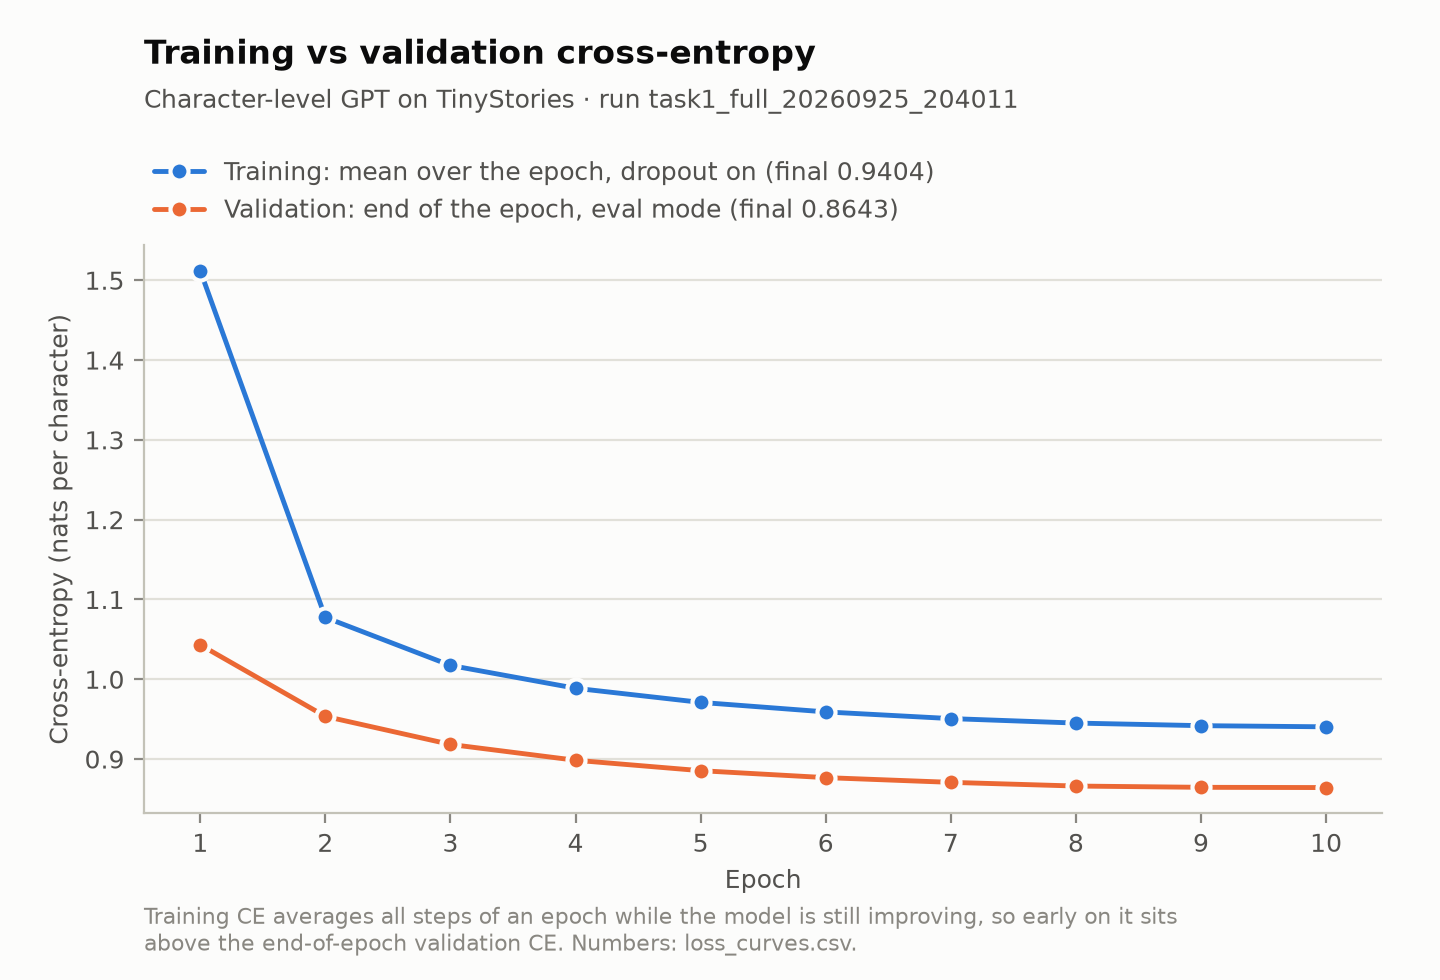

In [11]:
from IPython.display import Image, display

display(Image(filename=str(TASK1_DIR / "outputs" / RUN_ID / "curves" / "loss_curves.png")))


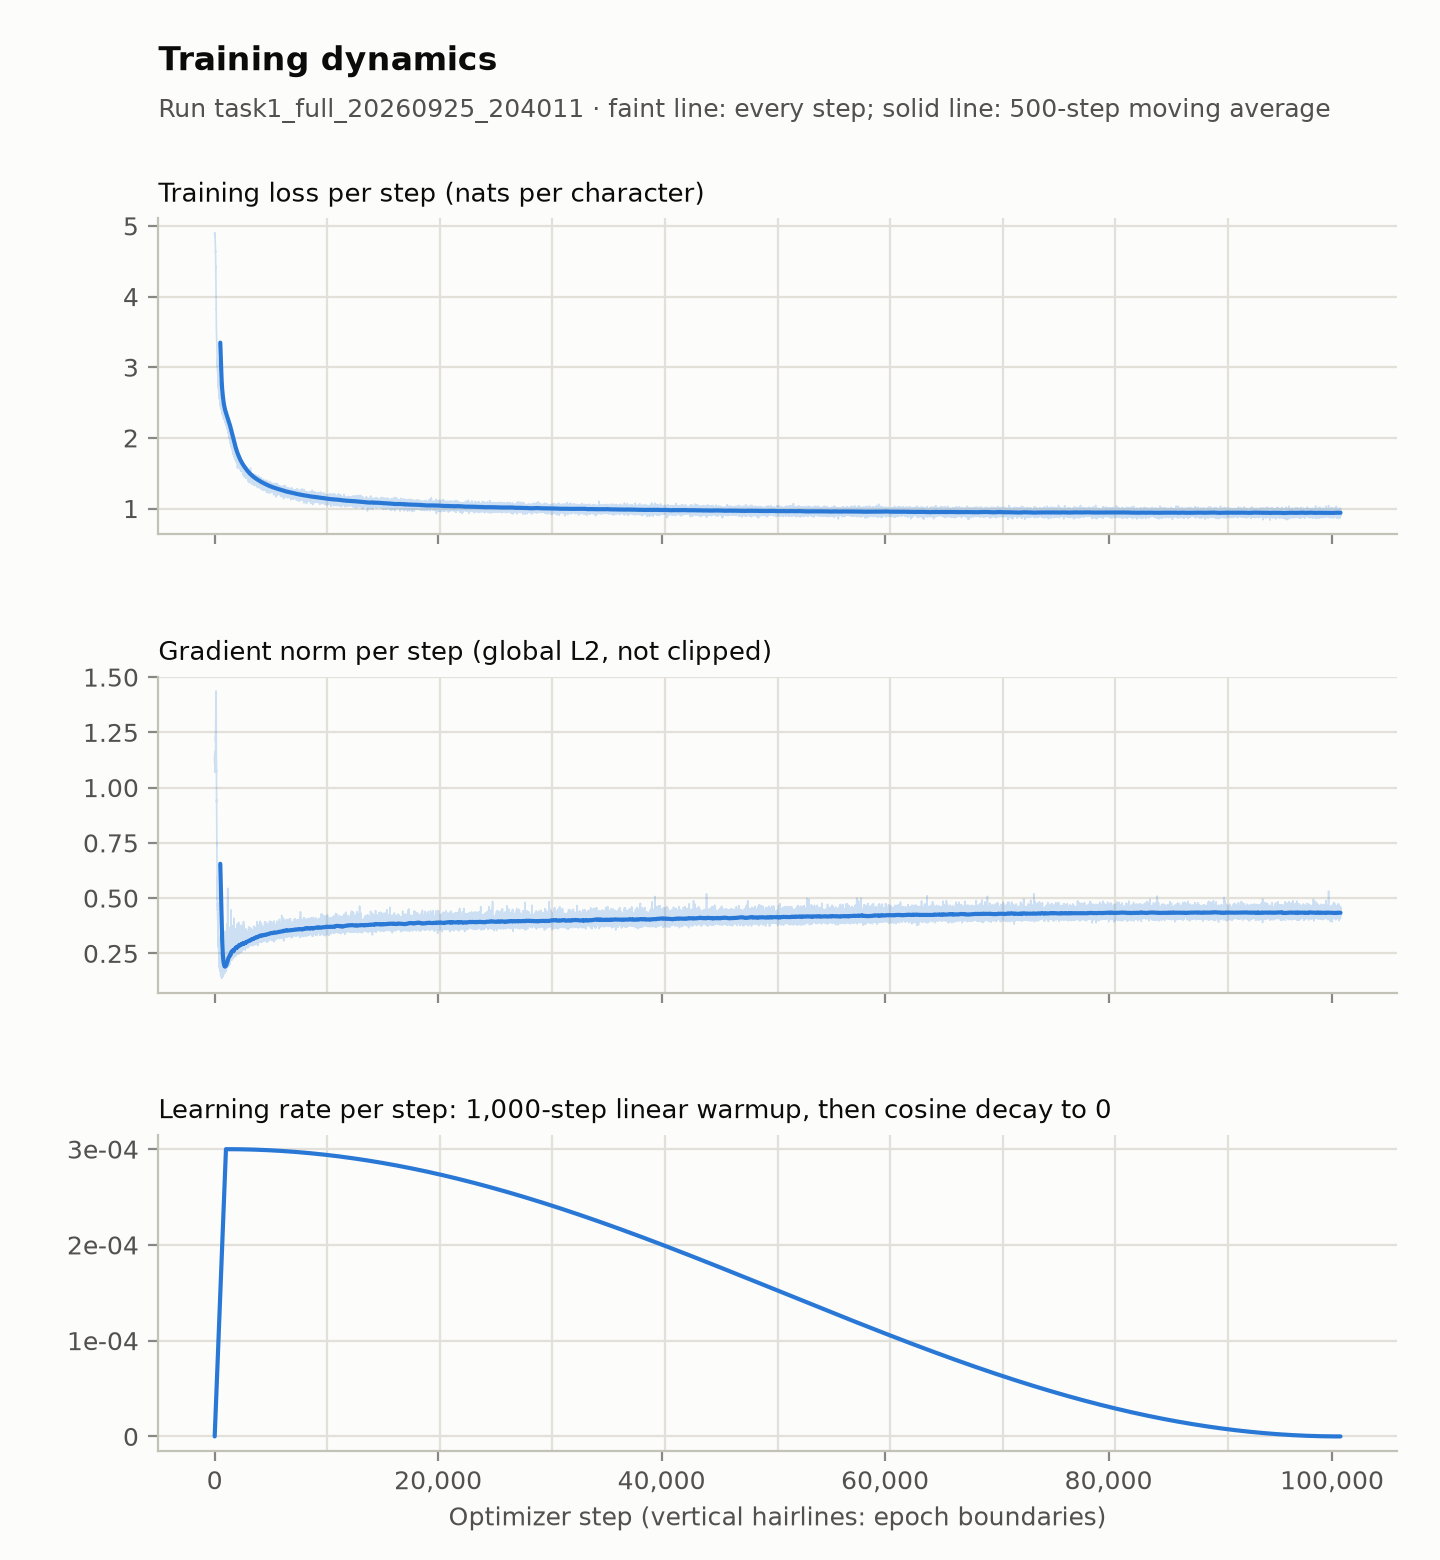

In [12]:
display(Image(filename=str(TASK1_DIR / "outputs" / RUN_ID / "curves" / "training_dynamics.png")))


## 11. Final evaluation metrics

From the committed `outputs/<run_id>/eval_epoch_9/metrics.json`, primary checkpoint `epoch_9.pt`
(lowest validation cross-entropy; also the final epoch).

In [13]:
with open(TASK1_DIR / "outputs" / RUN_ID / "eval_epoch_9" / "metrics.json") as f:
    metrics = json.load(f)

summary = {
    "validation_ce_nats": metrics["validation"]["ce_nats"],
    "training_ce_nats": metrics["train_eval_mode"]["ce_nats"],
    "generalization_gap_nats": metrics["generalization_gap"]["value_nats"],
    "validation_perplexity": metrics["validation"]["perplexity"],
    "training_perplexity": metrics["train_eval_mode"]["perplexity"],
    "validation_bpc": metrics["validation"]["bpc"],
    "training_bpc": metrics["train_eval_mode"]["bpc"],
    "validation_top1_accuracy": metrics["validation"]["top1_accuracy"],
    "training_top1_accuracy": metrics["train_eval_mode"]["top1_accuracy"],
    "char_distinct_1_2_3": [metrics["generation"]["primary_character_level"][k] for k in ("distinct_1", "distinct_2", "distinct_3")],
    "char_repeated_4gram_rate": metrics["generation"]["primary_character_level"]["repeated_4gram_rate"],
    "training_tokens_per_sec": metrics["training_run"]["training_tokens_per_sec"],
    "generation_tokens_per_sec": metrics["generation"]["tokens_per_sec"],
    "peak_gpu_memory_allocated_mib": metrics["training_run"]["peak_gpu_memory_allocated_bytes"] / 1024**2,
    "total_training_time_sec": metrics["training_run"]["total_training_time_seconds"],
    "nan_count": metrics["training_run"]["nan_count"],
}
print(json.dumps(summary, indent=2))


{
  "validation_ce_nats": 0.8642926901372148,
  "training_ce_nats": 0.8638971224188982,
  "generalization_gap_nats": 0.00039556771831661397,
  "validation_perplexity": 2.3733268147009032,
  "training_perplexity": 2.372388188885268,
  "validation_bpc": 1.2469107779375412,
  "training_bpc": 1.2463400943519902,
  "validation_top1_accuracy": 0.727477724890052,
  "training_top1_accuracy": 0.7275558692355168,
  "char_distinct_1_2_3": [
    0.0051,
    0.04361809045226131,
    0.1591919191919192
  ],
  "char_repeated_4gram_rate": 0.13086294416243655,
  "training_tokens_per_sec": 307816.5924640004,
  "generation_tokens_per_sec": 566.4159513799348,
  "peak_gpu_memory_allocated_mib": 444.07421875,
  "total_training_time_sec": 2705.139118,
  "nan_count": 0
}


## 12. Generation protocol

Settings recorded in `metrics.json` for the committed generation run:

In [14]:
print(json.dumps(metrics["generation"]["settings"], indent=2))


{
  "method": "temperature",
  "temperature": 0.8,
  "max_new_tokens": 200,
  "prompts": [
    "Once upon a time",
    "One day,",
    "Lily and Ben",
    "The little bird",
    "Tom was sad because"
  ],
  "samples_per_prompt": 10,
  "seed": 42,
  "batch_size": 1
}


## 13. Representative generated samples

One sample per prompt (5 prompts), from the committed `generations.jsonl` -- excluding the three
failure-analysis candidates shown in the next section.

In [15]:
generations_path = TASK1_DIR / "outputs" / RUN_ID / "eval_epoch_9" / "generations.jsonl"
with open(generations_path) as f:
    generations = [json.loads(line) for line in f]

print(f"Total generated samples: {len(generations)}\n")
for idx in [1, 12, 21, 33, 41]:
    sample = generations[idx]
    print(f"--- sample {idx} (prompt: {sample['prompt']!r}) ---")
    print(sample["text"])
    print()


Total generated samples: 50

--- sample 1 (prompt: 'Once upon a time') ---
Once upon a time, there was a bunny named Tim. Timmy was very excited because he was very happy and he was playing with his ball. He wanted to see what then he had seen many purples them up his toy car. Their mom sai

--- sample 12 (prompt: 'One day,') ---
One day, a night boy named Tim went to the park. His name was Tim. Tim wanted to go for a while with his mom. It liked to catch. He was a soft. He would you have something that sometimes too! Anna played toge

--- sample 21 (prompt: 'Lily and Ben') ---
Lily and Ben were playing in the park. They dropped their house and ran a car. They were playing a game. They loved to write the train. They sang and laughed. They looked at each other. They were sad.

They had a

--- sample 33 (prompt: 'The little bird') ---
The little bird was happy and he had made a great time. He wanted to jump or the pillow and sisters and go to the swings and their mom. So he couldn't go t

## 14. Failure-analysis candidates

Three cases selected for closer review (full write-up, with failure type, observation, and possible
improvement for each, in `failure_analysis.md`):

1. **Sample 8** (repetition) -- highest character- and word-level repeated 4-gram rate in the set.
2. **Sample 0** (semantic incoherence) -- locally fluent fragments that don't compose into a
   coherent story.
3. **Sample 46** (broken semantics/dialogue) -- mechanically well-formed dialogue punctuation
   wrapping nonsensical content.

See `failure_analysis.md` (this folder) for the full write-up.

In [16]:
for idx in [8, 0, 46]:
    sample = generations[idx]
    print(f"--- sample {idx} (prompt: {sample['prompt']!r}) ---")
    print(sample["text"])
    print()


--- sample 8 (prompt: 'Once upon a time') ---
Once upon a time, there was a little girl named Lily. She loved to play in the park. One day, a little girl named Lily went to the park. She made a loud noise. She was so excited for a magic. She didn't like the food

--- sample 0 (prompt: 'Once upon a time') ---
Once upon a time, there was a little girl named Lily. She had a big box to the mountain. One day, her mom saw a big box to sparkle and the spider. They also learned that her name cleaning the boy and had a send and a

--- sample 46 (prompt: 'Tom was sad because') ---
Tom was sad because he was too high and felt the wallets and the friends laughed inside. 

One day they find a big bear and the bird flew up and in the dark and said, "We will write as me fluffer?" They said, "We don't 



## 15. Reproducibility information

The primary checkpoint's SHA-256 is verified below directly against the value recorded in the raw
training log and `manifest.md` -- not just asserted.

In [17]:
import hashlib

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

checkpoint_path = TASK1_DIR / "checkpoints" / RUN_ID / f"epoch_{EPOCH}.pt"
computed_sha256 = sha256_file(checkpoint_path)
expected_sha256 = "5bd9af9bde778b4916696e18ecb435df040f9750037e7fb9918fa59ef04d398b"

print("Checkpoint:      ", checkpoint_path.relative_to(REPO_ROOT))
print("Computed SHA-256:", computed_sha256)
print("Expected SHA-256:", expected_sha256)
assert computed_sha256 == expected_sha256
print("\nSHA-256 verified -- checkpoint on disk exactly matches the committed/recorded evidence.")


Checkpoint:       task1_llm/khushi/checkpoints/task1_full_20260925_204011/epoch_9.pt
Computed SHA-256: 5bd9af9bde778b4916696e18ecb435df040f9750037e7fb9918fa59ef04d398b
Expected SHA-256: 5bd9af9bde778b4916696e18ecb435df040f9750037e7fb9918fa59ef04d398b

SHA-256 verified -- checkpoint on disk exactly matches the committed/recorded evidence.


In [18]:
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
print("Checkpoint epoch:      ", checkpoint["epoch"])
print("Checkpoint config == current config:", checkpoint["config"] == full_config)

model.load_state_dict(checkpoint["model_state_dict"])
print("\nCheckpoint weights loaded into the model architecture successfully (no retraining).")


Checkpoint epoch:       9
Checkpoint config == current config: True

Checkpoint weights loaded into the model architecture successfully (no retraining).


In [19]:
print("Run ID:               ", RUN_ID)
print("Raw training log:     ", (REPO_ROOT / "reproducibility" / "raw_logs" / "khushi" / f"{RUN_ID}.jsonl").relative_to(REPO_ROOT))
print("Reproducibility manifest:", (REPO_ROOT / "reproducibility" / "manifests" / "khushi" / "manifest.md").relative_to(REPO_ROOT))
print("Environment file:      ", (REPO_ROOT / "reproducibility" / "manifests" / "khushi" / "environment.txt").relative_to(REPO_ROOT))
print("Dataset:               roneneldan/TinyStories (Hugging Face), train split, seed 42, 100,000/10,000 story split")
print("Seed:                  42 (Python random, NumPy, PyTorch CPU/CUDA; also the split and generation-sampling seed)")


Run ID:                task1_full_20260925_204011
Raw training log:      reproducibility/raw_logs/khushi/task1_full_20260925_204011.jsonl
Reproducibility manifest: reproducibility/manifests/khushi/manifest.md
Environment file:       reproducibility/manifests/khushi/environment.txt
Dataset:               roneneldan/TinyStories (Hugging Face), train split, seed 42, 100,000/10,000 story split
Seed:                  42 (Python random, NumPy, PyTorch CPU/CUDA; also the split and generation-sampling seed)


## 16. Conclusion

The from-scratch, manually-implemented causal-attention GPT model (574,830 parameters) trained for
10 epochs on 100,000 TinyStories, reaching a validation cross-entropy of 0.8643 nats/char (perplexity
2.37, 72.75% top-1 next-character accuracy), with a near-zero generalization gap (+0.0004 nats) and
zero NaN/Inf events across all 100,760 optimizer steps. Generated text is locally fluent (correct
punctuation, common TinyStories names and phrasing) but shows the failure modes documented in
`failure_analysis.md` -- repetition, semantic incoherence, and nonsensical dialogue content -- typical
of a small character-level model at this training budget.

Training was stable across all 10 epochs (zero NaN/Inf events, monotonically decreasing validation
loss), and the near-zero generalization gap indicates little evidence of overfitting on this split.
These results are specific to this single locked architecture/hyperparameter configuration, evaluated
once on this data split; they are not evidence that this configuration is optimal, and no comparison
or claim of superiority relative to any other model (including Dipin's Task 2 models) is made here.
If continuing this work, the failure cases above point most directly at the 128-character context
window and the model's small parameter count as the first things to revisit for longer-range
coherence.

See `results.md` (this folder) for the full write-up and `metrics_report.csv` for the flat metrics
table.